# Batch BESS sizing across daily solar profiles

The goal of this notebook is to evaluate how the sizing optimisation model performs for different solar profiles.
Therefore, we run many daily optimizations (one per solar profile/day) and inspect the distribution of optimal battery sizing outputs for decision-making.
It is a way to stress test the battery optimization model.

Workflow:
1. Run Cells 1-3 to load data and set parameters.
2. Run Cell 4 to execute batch optimization.
3. Run Cells 5-7 to inspect results and decision metrics.

Notes:
- `battery_power_capacity` and `battery_energy_capacity` are optimized endogenously for each day.
- For tractability, start with a subset of days (for example 10-30), then scale to all days.

In [8]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root is on sys.path when running from notebooks/.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src import Optimizer

print(f"Using repo root: {repo_root}")

# create directory for results if it doesn't exist
results_dir = repo_root / "results"
results_dir.mkdir(exist_ok=True)
output_dir = results_dir / "02_optimization_results"
output_dir.mkdir(exist_ok=True)

Using repo root: c:\Users\Pc\Documents\GitHub\optimal-battery-sizing


In [2]:
# Load solar daily profiles from CSV.
solar_path = repo_root / "data" / "solar_profiles.csv"
solar_df = pd.read_csv(solar_path)

# Expected shape is (hours_per_day, number_of_days).
hours_per_day, n_days = solar_df.shape
print(f"Loaded solar profiles from: {solar_path}")
print(f"hours_per_day={hours_per_day}, number_of_days={n_days}")

# Show the first few day names and first rows.
display(solar_df.iloc[:5, :5])

Loaded solar profiles from: c:\Users\Pc\Documents\GitHub\optimal-battery-sizing\data\solar_profiles.csv
hours_per_day=24, number_of_days=365


,Day_0,Day_1,Day_2,Day_3,Day_4
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0


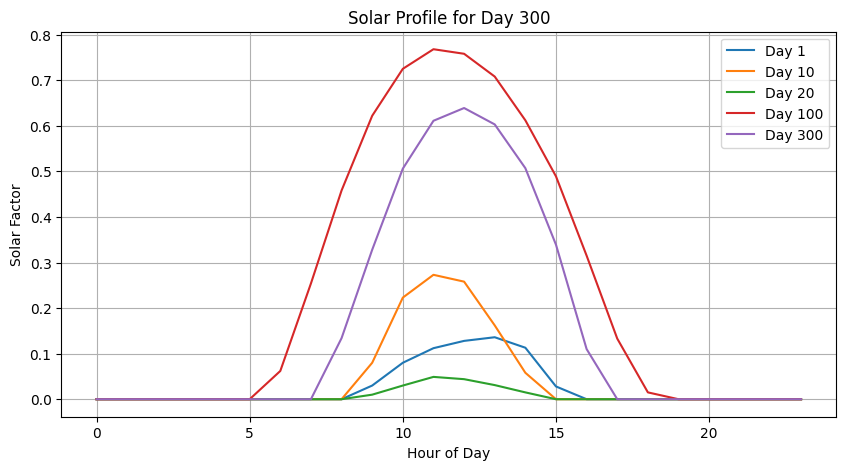

In [3]:
# Visually explore the solar profiles for the first few days.
selected_day_indices = [1, 10, 20, 100, 300]  # Example: [0, 10, 50]. Keep None to use first max_days_to_run days.
plt.figure(figsize=(10, 5))
for day_idx in selected_day_indices[:5]:  # Show the first 5 selected days
    plt.plot(solar_df.iloc[:, day_idx], label=f"Day {day_idx}")
plt.title(f"Solar Profile for Day {day_idx}")
plt.xlabel("Hour of Day")
plt.ylabel("Solar Factor")
plt.legend()
plt.grid()
plt.show()

In [4]:
# USER INPUTS: scenario and optimization assumptions.

# System assumptions
solar_capacity_mw = 300.0
efficiency = 0.90
battery_power_cost = 200_000.0
battery_energy_cost = 300_000.0
max_battery_power = 500.0
max_hours = 8.0
solver_name = "highs"
unmet_penalty = 1e9

# Tractability controls
max_days_to_run = None   # Set to None to run all days
selected_day_indices = None  # Example: [0, 10, 50]. Keep None to use first max_days_to_run days.

# Demand profile (must have same length as each daily solar profile).
# Option A: define a full demand array manually (preferred).
demand_profile = np.array([
    50, 45, 40, 38, 36, 38, 45, 60,
    75, 85, 90, 92, 90, 88, 86, 88,
    92, 95, 90, 80, 70, 65, 58, 52,
], dtype=float)

if len(demand_profile) != hours_per_day:
    raise ValueError(
        f"demand_profile length ({len(demand_profile)}) must match hours_per_day ({hours_per_day})."
    )

Start the optimization over the different avialble daily solar profiles (daily timeseries optimization).

In [5]:
# Build the list of days to run.
if selected_day_indices is not None:
    day_indices = [int(i) for i in selected_day_indices]
else:
    if max_days_to_run is None:
        day_indices = list(range(n_days))
    else:
        day_indices = list(range(min(int(max_days_to_run), n_days)))

print(f"Running {len(day_indices)} optimization(s) out of {n_days} available day profiles.")

records = []
batch_start = time.perf_counter()

for run_idx, day_idx in enumerate(day_indices, start=1):
    day_label = solar_df.columns[day_idx]
    solar_profile = solar_df.iloc[:, day_idx].to_numpy(dtype=float)

    t0 = time.perf_counter()
    model = Optimizer(solver_name=solver_name, unmet_penalty=unmet_penalty)
    model.add_solar(capacity=solar_capacity_mw, profile=solar_profile)
    model.add_storage(
        efficiency=efficiency,
        battery_power_cost=battery_power_cost,
        battery_energy_cost=battery_energy_cost,
        max_battery_power=max_battery_power,
        max_hours=max_hours,
    )
    model.add_load(demand=demand_profile)
    model.solve()
    res = model.get_results()
    t1 = time.perf_counter()

    records.append({
        "run_index": run_idx,
        "day_index": day_idx,
        "day_label": day_label,
        "battery_power_capacity_mw": res["battery_power_capacity"],
        "battery_energy_capacity_mwh": res["battery_energy_capacity"],
        "duration_hours": res["battery_energy_capacity"] / max(res["battery_power_capacity"], 1e-9),
        "total_unmet_mwh": res["total_unmet"],
        "objective_value": res["objective_value"],
        "solve_seconds": t1 - t0,
    })

    if run_idx % 10 == 0 or run_idx == len(day_indices):
        elapsed = time.perf_counter() - batch_start
        print(f"Completed {run_idx}/{len(day_indices)} in {elapsed:.1f}s")

results_df = pd.DataFrame(records)
total_elapsed = time.perf_counter() - batch_start
print(f"Batch done: {len(results_df)} runs in {total_elapsed:.2f}s")

Running 365 optimization(s) out of 365 available day profiles.
Completed 10/365 in 52.4s
Completed 20/365 in 105.3s
Completed 30/365 in 156.5s
Completed 40/365 in 197.3s
Completed 50/365 in 237.7s
Completed 60/365 in 278.7s
Completed 70/365 in 319.7s
Completed 80/365 in 363.9s
Completed 90/365 in 406.3s
Completed 100/365 in 445.6s
Completed 110/365 in 493.1s
Completed 120/365 in 541.9s
Completed 130/365 in 598.6s
Completed 140/365 in 639.2s
Completed 150/365 in 678.6s
Completed 160/365 in 723.8s
Completed 170/365 in 766.4s
Completed 180/365 in 810.0s
Completed 190/365 in 852.7s
Completed 200/365 in 897.0s
Completed 210/365 in 939.1s
Completed 220/365 in 983.3s
Completed 230/365 in 1028.5s
Completed 240/365 in 1074.6s
Completed 250/365 in 1117.5s
Completed 260/365 in 1161.8s
Completed 270/365 in 1207.6s
Completed 280/365 in 1253.6s
Completed 290/365 in 1301.1s
Completed 300/365 in 1344.8s
Completed 310/365 in 1388.1s
Completed 320/365 in 1428.8s
Completed 330/365 in 1471.9s
Completed 34

First thing to be noticed is that the optimization-based approach over a long time horizon is time comnsuming and potentially intractable when dealing with larger and more complex problems.

Let's explore the results.

In [6]:
# Inspect summary statistics and top cases.
summary = results_df[[
    "battery_power_capacity_mw",
    "battery_energy_capacity_mwh",
    "duration_hours",
    "total_unmet_mwh",
    "objective_value",
    "solve_seconds",
]].describe(percentiles=[0.1, 0.5, 0.9, 0.95])

#display(summary)
display(results_df)

print("Largest energy-capacity days:")
display(
    results_df.sort_values("battery_energy_capacity_mwh", ascending=False).head(10)[[
        "day_label", "battery_power_capacity_mw", "battery_energy_capacity_mwh", "duration_hours", "total_unmet_mwh"
    ]]
)

,run_index,day_index,day_label,battery_power_capacity_mw,battery_energy_capacity_mwh,duration_hours,total_unmet_mwh,objective_value,solve_seconds
0,1,0,Day_0,42.0,101.319376,2.412366,1069.48,1.069519e+12,4.907312
1,2,1,Day_1,-0.0,-0.000000,-0.000000,1459.90,1.459900e+12,4.466133
2,3,2,Day_2,-0.0,-0.000000,-0.000000,1479.40,1.479400e+12,4.255539
3,4,3,Day_3,-0.0,-0.000000,-0.000000,1489.00,1.489000e+12,4.787261
4,5,4,Day_4,-0.0,-0.000000,-0.000000,1570.30,1.570300e+12,5.304137
...,...,...,...,...,...,...,...,...,...
360,361,360,Day_360,-0.0,-0.000000,-0.000000,1603.30,1.603300e+12,4.249798
361,362,361,Day_361,-0.0,-0.000000,-0.000000,1581.40,1.581400e+12,4.428468
362,363,362,Day_362,-0.0,-0.000000,-0.000000,1581.10,1.581100e+12,4.351271
363,364,363,Day_363,-0.0,-0.000000,-0.000000,1631.80,1.631800e+12,6.264788


Largest energy-capacity days:


,day_label,battery_power_capacity_mw,battery_energy_capacity_mwh,duration_hours,total_unmet_mwh
89,Day_89,140.911111,806.486213,5.723368,0.00
111,Day_111,119.100000,784.561087,6.587415,0.00
98,Day_98,117.542222,780.871764,6.643330,0.00
100,Day_100,120.527778,778.974397,6.463028,0.00
108,Day_108,140.977778,775.812119,5.503081,0.00
101,Day_101,107.928889,771.701158,7.150089,0.00
86,Day_86,144.900000,769.287286,5.309091,55.39
99,Day_99,102.668519,768.538881,7.485633,0.00
102,Day_102,104.146296,767.273970,7.367271,0.00
226,Day_226,113.160000,763.690055,6.748763,0.00


In [9]:
# Save results of daily optimization to csv
results_df.to_csv(output_dir / "batch_daily_sizing_results.csv", index=False)

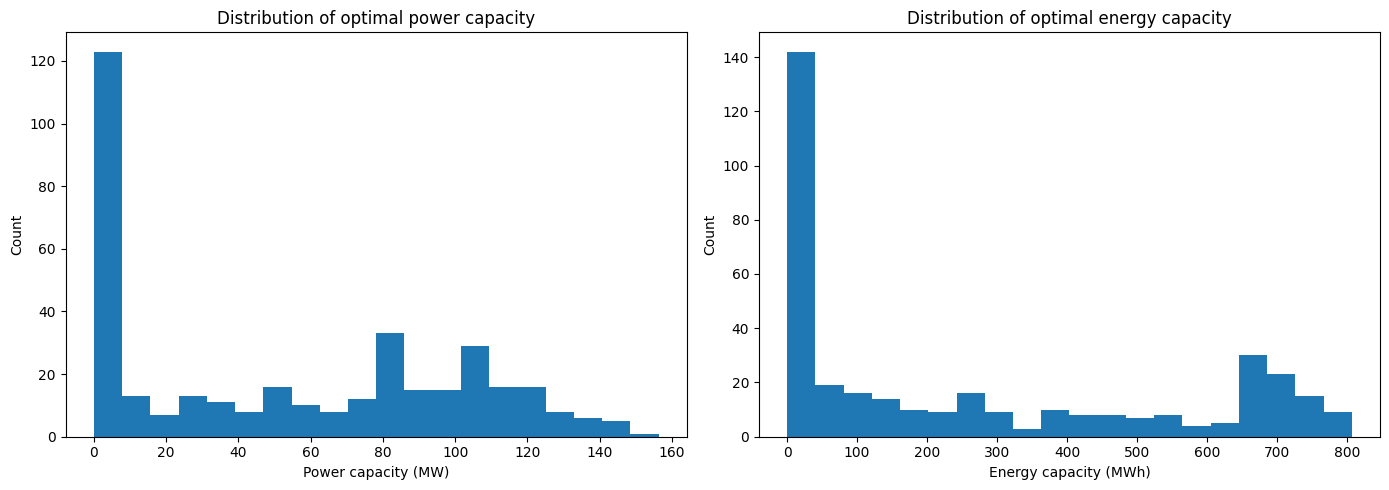

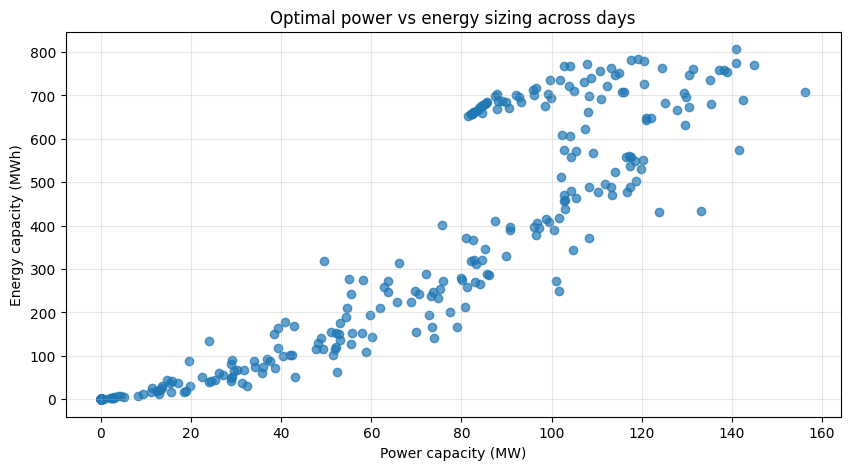

In [10]:
# Visual inspection for decision-making.

# Histograms of optimal power and energy capacities across days.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(results_df["battery_power_capacity_mw"], bins=20)
axes[0].set_title("Distribution of optimal power capacity")
axes[0].set_xlabel("Power capacity (MW)")
axes[0].set_ylabel("Count")

axes[1].hist(results_df["battery_energy_capacity_mwh"], bins=20)
axes[1].set_title("Distribution of optimal energy capacity")
axes[1].set_xlabel("Energy capacity (MWh)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig(output_dir / "capacity_histograms.png")
plt.show()

# Scatter plot of power vs energy capacities 
plt.figure(figsize=(10, 5))
plt.scatter(
    results_df["battery_power_capacity_mw"],
    results_df["battery_energy_capacity_mwh"],
    alpha=0.7,
)
plt.title("Optimal power vs energy sizing across days")
plt.xlabel("Power capacity (MW)")
plt.ylabel("Energy capacity (MWh)")
plt.grid(True, alpha=0.3)
plt.savefig(output_dir / "power_vs_energy_scatter.png")
plt.show()

The chart above summarizes the results of the optimization against different solar daily profiles, and in particular it shows the optmimal battery sizing for each day individually considered (in this case, all the 365 days of an year). 

Results show that in some days, the model does not install any battery. This is likely due to scarsity of solar generation which is not enough to supply the loads and to charge the battery and therefore battery installation is useless. The model is forced to accept a high rate of unmet load and therefore a high total cost. 

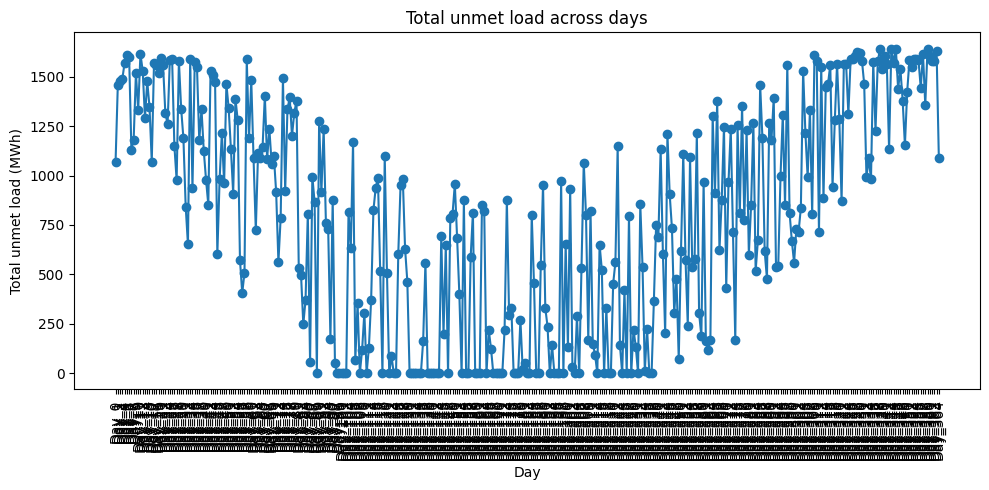

In [11]:
# Plot total unmet load across days
plt.figure(figsize=(10, 5))
plt.plot(results_df["day_label"], results_df["total_unmet_mwh"], marker='o', linestyle='-')
plt.title("Total unmet load across days")
plt.xlabel("Day")
plt.ylabel("Total unmet load (MWh)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Conclusions

After having evaluate the optimal battery sizing algorithm against different solar profiles (over a year), 
- how to choose the optimal battery size? 
- how suitable this model is for finding the optimal battery size? 

This model is a good first-order optimization model for sizing a battery under a known load and solar profile. Different solar profiles can be used as demostrated in the analysis above. However, when considering consecutives days in cronological order as in a year, this tools is not suitable to select the optimal battery over a year because it is still confined into a "single-day" logic for the optimization. 

This model is suitable for screening, sensitivity analysis, and understanding the trade-off between battery power and energy capacity. However, choosing the actual project battery requires one fixed design to be evaluated across the full year, against reliability and economic criteria, not just daily optimal solutions. Therefore, the model is suitable for generating candidate sizes and understanding sizing drivers, but not sufficient on its own for final battery selection.

This means that this model is good for answering: “For this assumed day/profile, what is the least-cost battery that can make the system feasible?” but it is not enough to answer: “What battery should I build for the site under real uncertainty over a year or multiple years?”

# Single optimization over full year

Alternatively, instead of running multiple sequential optimization problems for each time step (every day), to find the a first guess optmial battery size over the full horizon provided, a full year single optimization could be run.

This section evaluates the tractability of this approach. The workflow involves:

- Aggregate provided solar profiles into a single year-long input
- Aggregate available load profiles into a single year-long input
- Run optimization 

In [12]:
# create a single-column df for solar profiles
solar_df_single_column = solar_df.melt(var_name="day_label", value_name="value")
# extract the solar yearly profile for model injestion
solar_profile_yearly = solar_df_single_column["value"].to_numpy(dtype=float)

# create a single-column df for demand profile (demand profile is the same for all days, so we can repeat it for each day)
demand_df_single_column = pd.DataFrame({
    "day_label": np.repeat(solar_df.columns, hours_per_day),
    "value": np.tile(demand_profile, n_days)
})
# extract the demand yearly profile for model ingestion
demand_profile_yearly = demand_df_single_column["value"].to_numpy(dtype=float)


In [13]:
import logging
logging.basicConfig(level=logging.INFO) # Enables matrix generation prints

# Define and solve the optimization model
print("Initializing and configuring the optimization model...")
model = Optimizer(solver_name=solver_name, unmet_penalty=unmet_penalty)
model.add_solar(capacity=solar_capacity_mw, profile=solar_profile_yearly)
model.add_storage(
    efficiency=efficiency,
    battery_power_cost=battery_power_cost,
    battery_energy_cost=battery_energy_cost,
    max_battery_power=max_battery_power,
    max_hours=max_hours,
)
model.add_load(demand=demand_profile_yearly)

# Enable linopy logging for detailed output
logging.getLogger("linopy").setLevel(logging.INFO)

print(f"Starting the solver ({solver_name}) for the full yearly profile...")
start_solve_time = time.time()
model.solve()
end_solve_time = time.time()
solve_duration = end_solve_time - start_solve_time
print(f"Solver finished in {solve_duration:.2f} seconds.")

results = model.get_results()

Initializing and configuring the optimization model...
Starting the solver (highs) for the full yearly profile...


INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 24.20it/s]
INFO:linopy.io: Writing time: 124.47s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 43802 primals, 52561 duals
Objective: 2.81e+14
Solver model: available
Solver message: Optimal



Solver finished in 1410.01 seconds.


The optimization took a long time to run (1500sec) which is still lower then the execution time of the daily optmization in series over the year. 

In [14]:
# Extract and display the results
duration_hours = results["battery_energy_capacity"] / max(results["battery_power_capacity"], 1e-9)
print("=== Optimized Battery Size ===")
print(f"Power capacity (MW):  {results['battery_power_capacity']:.3f}")
print(f"Energy capacity (MWh): {results['battery_energy_capacity']:.3f}")
print(f"Duration (h):          {duration_hours:.3f}")
print()
print("=== System Performance ===")
print(f"Solar generation:         {results['sol'].sum():.2f} MWh")
print(f"Battery discharge:        {results['s_discharge'].sum():.2f} MWh")
print(f"Battery charge:           {results['s_charge'].sum():.2f} MWh")
print(f"Total unmet load (MWh):   {results['total_unmet']:.2f} MWh")

=== Optimized Battery Size ===
Power capacity (MW):  343.874
Energy capacity (MWh): 2750.992
Duration (h):          8.000

=== System Performance ===
Solar generation:         331351.50 MWh
Battery discharge:        100509.57 MWh
Battery charge:           111677.30 MWh
Total unmet load (MWh):   281336.23 MWh


With a full year simulation the result of the optimal battery sizing are much larger (Pbat= 340MW and Ebat=2750 Mwh) compared to the time series daily optimization, where the max values found where around Pbat=160Mw and Ebat=800MWh. This formulation of the optmization problem takes into account the seasonality of the whole year. Its result is completely different from the daily approach and it is much larger. It leads to huge sizes and therefore high costs. However, unmet load is still relevant from the results and clearly does not benefit from such a big size. This is likely not the best configuration. So other methods should be pursued for optimal battery size.

Please note that to find more accurate result, the actual timeseries data over the whole year of load demand should be available to the modeller. In this case we have only repeated every day the daily load initially provided. This probably leads to an overestimation of the demand over the year.

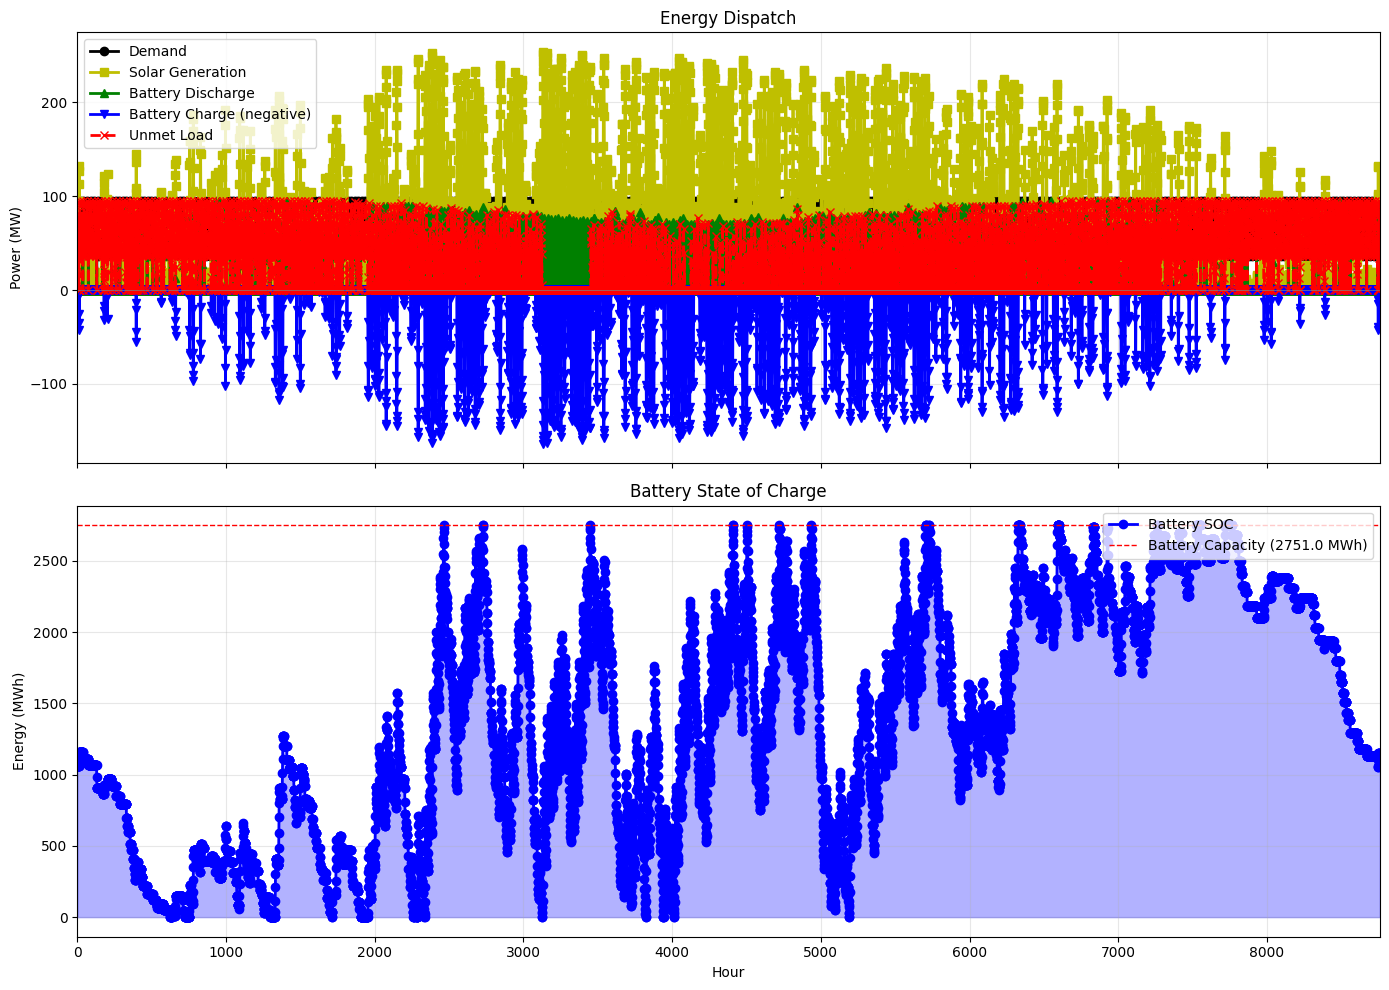

In [15]:
# Visualize the results over the full year
_ = model.plot_dispatch(show=False, save_path=output_dir / "full_year_dispatch.png")

The picture above with the time line of the battery operations shows those repetitive behaviours for the unmet load and the battery discharge because both variables follow the repetitive, user-inputted, load timeseries, which is the same for all days and gives this strange behaviour to the results.